<a href="https://colab.research.google.com/github/nkocjan/computational-intelligence-methods/blob/dev/lab01/lab01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Zadanie 1**


Proszę stworzyć zestaw punktów należących do dwóch klas: K1 i K2. Punkty z klasy K1 powinny być losowane z rozkładu normalnego o średniej [0, -1] i wariancji 1. Punkty z klasy K2 powinny pochodzić z rozkładu normalnego o średniej [1, 1] i wariancji 1. Całościowo zbiór powinien zawierać 200 punktów, po 100 dla każdej klasy.


In [ ]:
from sklearn.linear_model import Perceptron
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import pandas as pd


K1 = np.random.normal([0,-1], 1, [100,2])
K2 = np.random.normal([1,1], 1, [100,2])

Należy wybrać zbiory uczące o następującej liczebności: 5, 10, 20 oraz 100.

 Dla każdego wariantu podziału znalezy znaleźć równanie prostej, która najlepiej oddziela klasy K1 i K2.Uzyskaną prostą należy zaprezentować razem z punktami testowymi i linią (hiperpłaszczyzną), która oddziela klasy. Następnie należy ocenić to jak dobrze klasyfikator działa od proporcji danych uczących i testujących.


1.0


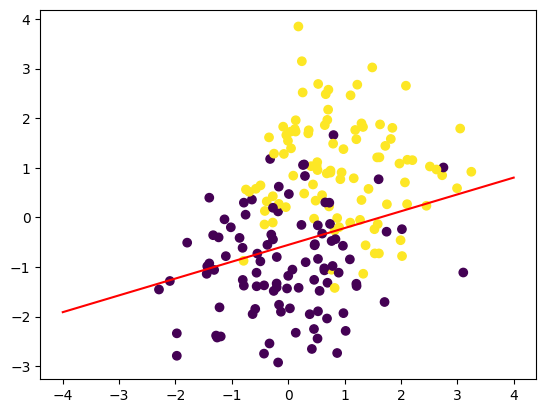

0.9


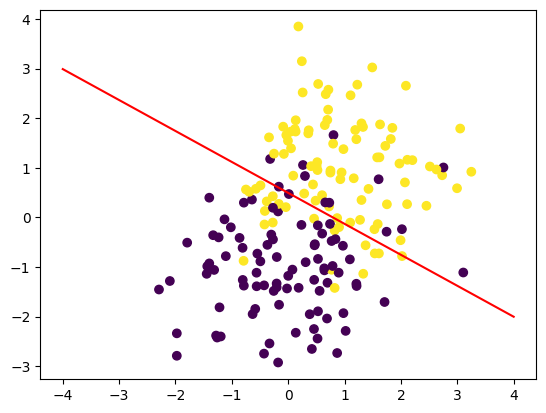

0.85


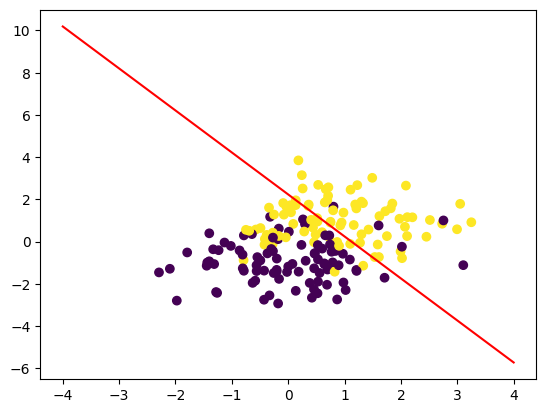

0.87


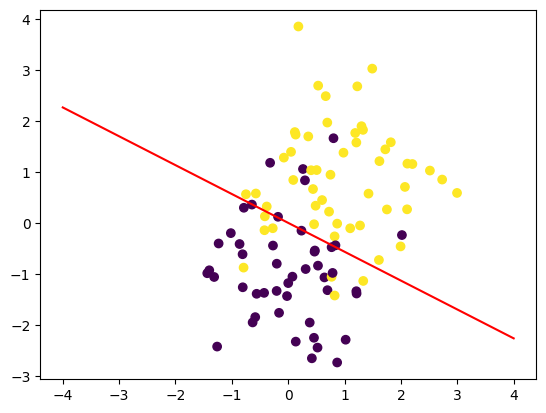

In [ ]:
X = np.vstack((K1, K2))
y = np.hstack((np.zeros(100), np.ones(100)))

train_sizes = [5, 10, 20, 100]

results = []

for i, train_size in enumerate(train_sizes):
    X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=train_size, random_state=0)

    perceptron = Perceptron(tol=1e-3, max_iter=500)
    perceptron.fit(X_train, y_train)

    print(perceptron.score(X_train, y_train))

    x1 = np.linspace(-4,4,100)
    x2 = -(1./perceptron.coef_[0][1])*(perceptron.coef_[0][0]*x1+perceptron.intercept_[0])
    plt.plot(x1, x2, '-r')
    plt.scatter(np.array(X_test)[:,0], np.array(X_test)[:,1], c=y_test)
    plt.show()


Analiza próbek benzyny wykazała że może ona być przypisana do dwóch klas czystości A i B (dla potrzeb zadania można je oznaczyć 0 i 1). Proszę skorzystać z pliku fuel.txt, w którym pierwsze trzy kolumny to właściwości fizykochemiczne próbek, czwarta kolumna - klasa czystości.

Proszę sprawdzić skuteczność sieci opartej o pojedynczy neuron do klasyfikacji w tym problemie, porównując wyniki dla pięciokrotnego uczenia sieci. Proszę potraktować wszystkie dane jako dane uczące.

In [ ]:
data = pd.read_csv('./fuel.txt', delimiter=",")

In [ ]:
numeric_cols = data.select_dtypes(include=['float64']).columns

print(data)

data[numeric_cols] = (data[numeric_cols] - data[numeric_cols].min()) / (data[numeric_cols].max() - data[numeric_cols].min())

print(data.head())

print(data.describe())

    c_1       c_2       c_3 purity_class
0   1.0  0.000000  0.180624            B
1   1.0  0.000000  0.045393            B
2   1.0  0.000000  0.073017            B
3   1.0  0.000000  0.442112            B
4   0.0  0.793931  1.000000            A
..  ...       ...       ...          ...
95  0.0  0.467861  1.000000            A
96  0.0  0.904705  1.000000            A
97  1.0  0.000000  0.026242            B
98  0.0  0.969369  1.000000            A
99  0.0  0.997282  1.000000            A

[100 rows x 4 columns]
   c_1       c_2       c_3 purity_class
0  1.0  0.000000  0.180624            B
1  1.0  0.000000  0.045393            B
2  1.0  0.000000  0.073017            B
3  1.0  0.000000  0.442112            B
4  0.0  0.793931  1.000000            A
              c_1         c_2         c_3
count  100.000000  100.000000  100.000000
mean     0.569187    0.360109    0.538549
std      0.494277    0.439412    0.439087
min      0.000000    0.000000    0.000000
25%      0.000000    0.000000    0